In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append("..")

import itertools
import json
from functools import partial
from statistics import mean
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import disable_caching
from datasets.utils.logging import disable_progress_bar
from hydra import compose, initialize
from tqdm import trange

from hallucinations_kg.data.postprocessing import (
    add_allowed_nodes_and_relationships,
    parse_graph,
    postprocess_ents_rels,
)
from hallucinations_kg.data.utils import get_processed_dataset
from hallucinations_kg.defaults import PLOTS_PATH
from hallucinations_kg.metrics import auc_pr
from hallucinations_kg.models.baselines.selfcheckgpt import (
    SelfCheckGPTNLIPredictor,
    SelfCheckGPTPredictor,
)
from hallucinations_kg.models.predictor import (
    FactOccurrencePredictor,
    RandomFactPredictor,
)
from hallucinations_kg.models.prompt_predictor import FactPromptPredictor, FactTextPromptPredictor
from hallucinations_kg.models.sentence_predictor import (
    MostFrequentSentencePredictor,
    RandomSentencePredictor,
)
from hallucinations_kg.prediction.prediction import (
    add_sentence_predictor_results,
)
from hallucinations_kg.utils.logging import set_error_level

disable_progress_bar()
disable_caching()
sns.set_context("paper")
sns.set_style("whitegrid")
sns.set_palette("colorblind")
set_error_level()

## Loading

In [3]:
with initialize(version_base="1.3", config_path=str("config")):
    cfg = compose(
        config_name="predict",
        overrides=[
            "processed_dataset=fava-sampling_sentence_with_prompt_answers",
            "llm=api/Llama-3.1-70B-Instruct",
        ],
    )

dataset = get_processed_dataset(cfg.processed_dataset)

In [4]:
response_column = cfg.processed_dataset.original_dataset.response_column
restrictions_column = cfg.processed_dataset.original_dataset.response_column
response_sentences_column = cfg.processed_dataset.original_dataset.response_sentences_column
samples_column = cfg.processed_dataset.original_dataset.samples_column

dataset = dataset.map(
    partial(
        add_allowed_nodes_and_relationships,
        restrictions_column=restrictions_column,
        response_sentences_column=response_sentences_column,
    )
)
dataset = dataset.map(
    partial(
        parse_graph,
        samples_column=samples_column,
        sentences_column=response_sentences_column,
        restrict=True,
    )
)
dataset = dataset.map(partial(postprocess_ents_rels, response_column=response_column))

In [5]:
PREDICTOR_AGGREGATION_FUNCTIONS = [
    (FactOccurrencePredictor, mean),
    (FactOccurrencePredictor, max),
    (RandomFactPredictor, mean),
    (MostFrequentSentencePredictor, None),
    (RandomSentencePredictor, None),
    (FactPromptPredictor, mean),
    (FactPromptPredictor, max),
    (FactTextPromptPredictor, mean),
    (FactTextPromptPredictor, max),
    (SelfCheckGPTPredictor, None),
    (SelfCheckGPTNLIPredictor, None),
]
for n_samples in trange(1, 20 + 1):
    for name, ds in dataset.items():
        y_true = list(itertools.chain.from_iterable(ds["binary_annotation"]))
        ds = ds.map(
            partial(
                add_sentence_predictor_results,
                sentences_column=response_sentences_column,
                samples_column=samples_column,
                y_true=y_true,
                predictor_aggregation_functions=PREDICTOR_AGGREGATION_FUNCTIONS,
                n_samples=n_samples,
            ),
            num_proc=4,
        )
        dataset[name] = ds

100%|██████████| 20/20 [00:52<00:00,  2.60s/it]


In [6]:
df = dataset["test"].to_pandas()

In [7]:
SENTENCE_SCORE_COLUMNS = [col for col in df.columns if col.startswith("sent_score_")]
COLUMNS_TO_EXPLODE = [
    response_sentences_column,
    f"{response_sentences_column}_graph",
    "binary_annotation",
] + SENTENCE_SCORE_COLUMNS

sentence_df = df.explode(COLUMNS_TO_EXPLODE)

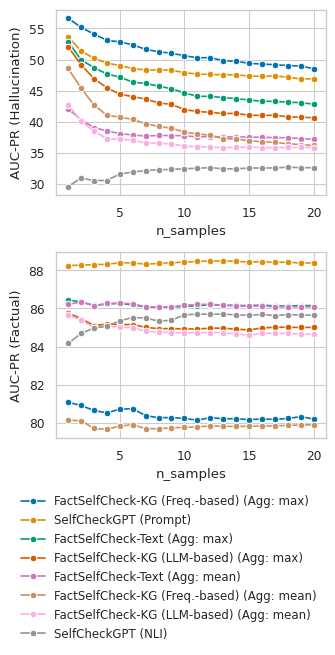

In [8]:
def parse_params(params: str) -> dict[str, Any]:
    return json.loads(params.replace("'", '"'))


results = []
for filter_not_na in [False]:
    for col in SENTENCE_SCORE_COLUMNS:
        if filter_not_na:
            y_pred = sentence_df[sentence_df[col].notna()][col]
            y_true = sentence_df[sentence_df[col].notna()].binary_annotation.to_numpy(dtype=float)
        else:
            y_pred = sentence_df[col]
            y_true = sentence_df.binary_annotation.to_numpy(dtype=float)
            y_pred = [x if pd.notna(x) else 0.5 for x in y_pred]

        y_true_factual = 1 - y_true
        y_pred_factual = 1 - np.array(y_pred)

        auc_pr_factual = auc_pr(y_true_factual, y_pred_factual) * 100
        results.append(
            {
                "filter_not_na": filter_not_na,
                "col": col,
                **parse_params(col.split("__")[-1]),
                "auc_hallucination": auc_pr(y_true, y_pred) * 100,
                "auc_factual": auc_pr_factual,
            }
        )

results = pd.DataFrame(results)

mask = (
    results.fact_predictor.str.contains("FactSelfCheck-KG")
    | results.fact_predictor.str.contains("FactSelfCheck-Text")
    | results.sentence_predictor.str.contains("SelfCheckGPT")
)


def get_method_name(row: pd.Series) -> str:
    if row["sentence_predictor"] == "SelfCheckGPT-reproduced":
        return "SelfCheckGPT (Prompt)"
    elif row["sentence_predictor"] == "SelfCheckGPT-NLI-reproduced":
        return "SelfCheckGPT (NLI)"
    else:
        if row["fact_predictor"] == "FactOccurrence":
            fact_predictor = "FactKGOccurrence"
        elif row["fact_predictor"] == "FactPrompt":
            fact_predictor = "FactKGPrompt"
        elif row["fact_predictor"] == "FactTextPrompt":
            fact_predictor = "FactTextPrompt"
        else:
            fact_predictor = row["fact_predictor"]
        if fact_predictor == "KGSamplesMeanSize":
            return f"{fact_predictor}"
        else:
            return f"{fact_predictor} (Agg: {row['agg_func']})"


results["Method"] = results.apply(get_method_name, axis=1)
results["Method"] = results["Method"].str.replace("Frequency", "Freq.")
to_report = results[~results.filter_not_na & mask][
    ["Method", "auc_hallucination", "auc_factual", "n_samples"]
]
to_report = to_report.rename(
    columns={
        "auc_hallucination": "AUC-PR (Hallucination)",
        "auc_factual": "AUC-PR (Factual)",
        "fact_predictor": "Fact Predictor",
        "sentence_predictor": "Sentence Predictor",
        "agg_func": "Sentence Aggregation",
    }
)

fig, axes = plt.subplots(2, 1, figsize=(3.5, 5))
hue_order = (
    to_report[to_report.n_samples == 20]
    .sort_values(by="AUC-PR (Hallucination)", ascending=False)
    .Method.tolist()
)
g = sns.lineplot(
    data=to_report,
    x="n_samples",
    y="AUC-PR (Hallucination)",
    hue="Method",
    ax=axes[0],
    marker="o",
    hue_order=hue_order,
)
g = sns.lineplot(
    data=to_report,
    x="n_samples",
    y="AUC-PR (Factual)",
    hue="Method",
    ax=axes[1],
    marker="o",
    hue_order=hue_order,
)
axes[0].get_legend().remove()
fig.tight_layout()

sns.move_legend(
    axes[1],
    "lower center",
    bbox_to_anchor=(0.42, -1.15),
    ncol=1,
    title=None,
    frameon=False,
    fontsize=8.5,
)
plt.savefig(
    PLOTS_PATH / "ablation_n_samples_sentence_fava_extended.pdf", dpi=600, bbox_inches="tight"
)